# Exploratory Data Analysis

# Steps
- create baseline - Linear Regression
- create comparative method - XGBoost
- Data exploration 
    - missing data
    - distribution of data (labels)
    - feature extraction and feature selection
- modeling
    - hyperparameter tuning
    - training 
    - testing
- inference (model serving)
- monitoring and observability
- mlflow for MLOps


In [24]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,roc_auc_score

In [11]:
# read data
raw_data = pd.read_excel("../data/default_of_credit_card_clients.xls",skiprows=[0])
raw_data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [14]:
raw_data.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [ ]:
#raw_data.info

n_ones = (raw_data["default payment next month"]==1).sum()
n_zeros = (raw_data["default payment next month"]==0).sum()

print(n_ones,n_zeros)

# class imbalance

6636 23364


default payment next month
non-default    23364
default         6636
Name: count, dtype: int64


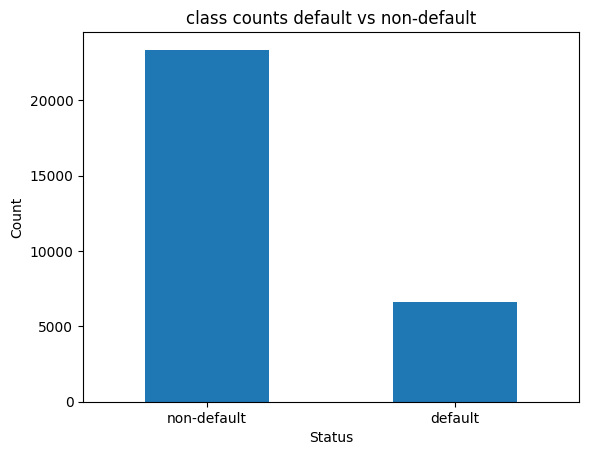

In [19]:
import matplotlib.pyplot as plt

counts = raw_data["default payment next month"].value_counts()
counts.index = counts.index.map({0:"non-default", 1:"default"})
print(counts)
counts.plot(kind="bar",title="class counts default vs non-default")
plt.ylabel("Count")
plt.xlabel("Status")
plt.xticks(rotation=0)
plt.show()


In [20]:
# rename the target column
raw_data.rename(columns={'default payment next month':'default'},inplace=True)

# drop the ID column
raw_data.drop('ID',axis=1, inplace=True)

# print columns after cleaning

print (raw_data.columns)

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='object')


In [21]:
# print data overview

print (raw_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

In [22]:
#print the statistical summary

print (raw_data.describe())

            LIMIT_BAL           SEX     EDUCATION      MARRIAGE           AGE  \
count    30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean    167484.322667      1.603733      1.853133      1.551867     35.485500   
std     129747.661567      0.489129      0.790349      0.521970      9.217904   
min      10000.000000      1.000000      0.000000      0.000000     21.000000   
25%      50000.000000      1.000000      1.000000      1.000000     28.000000   
50%     140000.000000      2.000000      2.000000      2.000000     34.000000   
75%     240000.000000      2.000000      2.000000      2.000000     41.000000   
max    1000000.000000      2.000000      6.000000      3.000000     79.000000   

              PAY_0         PAY_2         PAY_3         PAY_4         PAY_5  \
count  30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean      -0.016700     -0.133767     -0.166200     -0.220667     -0.266200   
std        1.123802      1.197186

In [25]:
# features and target
X = raw_data.drop('default',axis=1)
y = raw_data['default']

In [ ]:
# train, val, test

In [26]:
# train, test

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [69]:
# train, test

X_train_new,X_valid,y_train_new,y_valid = train_test_split(X_train,y_train, test_size=0.2, random_state=42)

In [70]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.fit_transform(X_valid)
X_test = scaler.fit_transform(X_test)


In [28]:
# Train the model

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)


LogisticRegression(max_iter=1000)

In [33]:
# prediction 
y_pred = model.predict(X_test)


In [34]:
# Evaluation 
# Classificatiion
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.68      0.24      0.36      1313

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [35]:
# confusion matrix

print (confusion_matrix(y_test,y_pred))

[[4538  149]
 [ 993  320]]


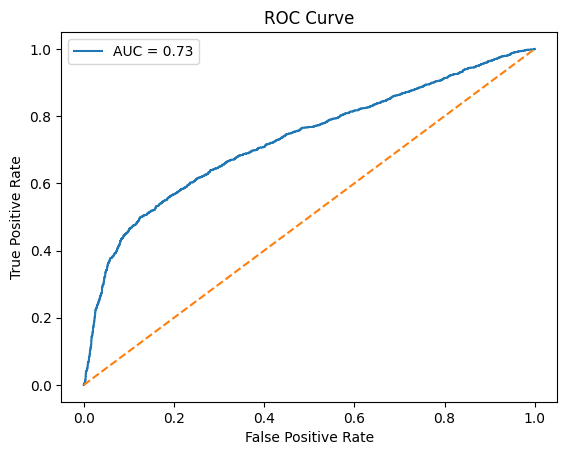

In [37]:
#ROC
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr,tpr, label = "AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [ ]:
# https://www.geeksforgeeks.org/machine-learning/how-to-optimize-logistic-regression-performance/

In [38]:
import numpy as np

param_grid = [
    
    {'penalty':['l1','l2','elasticnet','none'],
    'C' : np.logspace(-4,4,20),
    'solver': ['lbfgs','newton-cg','liblinear','sag','saga'],
    'max_iter'  : [100,1000,2500,5000]}
    
]

In [39]:
#get the best possible combination of hyperparameters

from sklearn.model_selection import GridSearchCV
clf = GridSearchCV(model,param_grid=param_grid,cv=3, verbose=True)
clf

GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000),
             param_grid=[{'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                          'max_iter': [100, 1000, 2500, 5000],
                          'penalty': ['l1', 'l2', 'elasticnet', 'none'],
                          'solver': ['lbfgs', 'newton-cg', 'liblinear', 'sag',
                                     'saga']}],
             verbose=True)

In [40]:
clf

GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000),
             param_grid=[{'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                          'max_iter': [100, 1000, 2500, 5000],
                          'penalty': ['l1', 'l2', 'elasticnet', 'none'],
                          'solver': ['lbfgs', 'newton-cg', 'liblinear', 'sag',
                                     'saga']}],
             verbose=True)

In [41]:
# apply best parameters to Logistic regression
best_clf = clf.fit(X_train,y_train)
best_clf.best_estimator_

Fitting 3 folds for each of 1600 candidates, totalling 4800 fits


/Users/nicholus/Documents/GitHub/credit-card-default/card_default/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/nicholus/Documents/GitHub/credit-card-default/card_default/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/nicholus/Documents/GitHub/credit-card-default/card_default/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/nicholus/Documents/GitHub/credit-card-default/card_default/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/nicholus/Documents/GitHub/credit-card-default/card_default/lib/python3.9/site

LogisticRegression(C=np.float64(0.23357214690901212), penalty='l1',
                   solver='liblinear')

In [42]:
print(f'accuracy - : {best_clf.score(X_train,y_train):.3f}')

accuracy - : 0.811


In [43]:
# testing 
# prediction 
y_pred = best_clf.predict(X_test)

# Evaluation 
# Classificatiion
print(classification_report(y_test,y_pred))



              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.36      1313

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



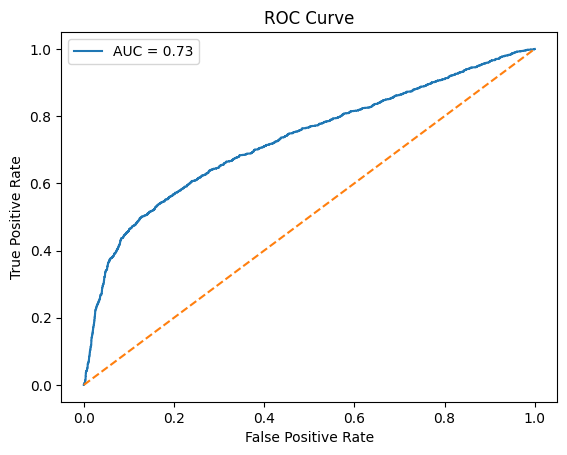

In [44]:
#ROC
y_prob = best_clf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr,tpr, label = "AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [47]:
# xgb

from xgboost import XGBClassifier
bst = XGBClassifier(n_estimators=600, max_depth=6,learning_rate=0.02,objective='binary:logistic')

bst.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [49]:
y_pred = bst.predict(X_test)
# Classificatiion
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.68      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



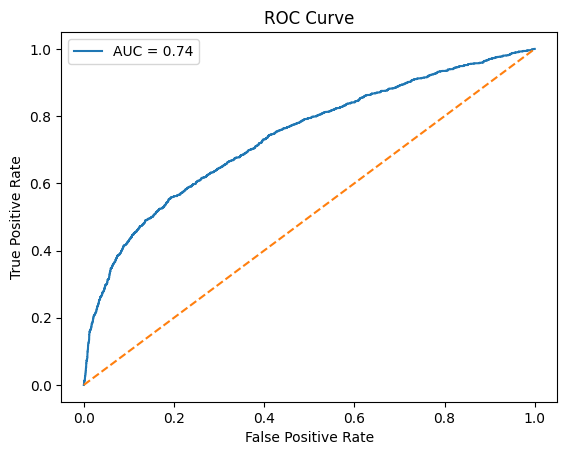

In [50]:
#ROC
y_prob = bst.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr,tpr, label = "AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [66]:
from xgboost import XGBClassifier
scale_pos_weight = 23364/6636
base_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    learning_rate=0.05,
    n_estimators=500,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,  # set below
    n_jobs=-1,
    early_stopping_rounds=50,
    random_state=42
)

In [78]:
from xgboost import XGBClassifier
scale_pos_weight = 23364/6636
base_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,  # set below
    n_jobs=4,
    random_state=42
)

param_dist = {
    "n_estimators": [300, 500],
    "learning_rate": [0.05, 0.1],
    "max_depth": [4,6,8],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8,0.9],
    "colsample_bytree": [0.8,0.9],
    "gamma": [0, 0.01, 0.1],
    "reg_alpha": [0.0, 0.01, 0.1],
    "reg_lambda": [0.1, 1.0, 2.0]
}

In [67]:
param_dist = {
    "n_estimators": [300, 500],
    "learning_rate": [0.05, 0.1],
    "max_depth": [4,6,8],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8,0.9],
    "colsample_bytree": [0.8,0.9] # remove heavy regularization params
}

In [79]:
from xgboost import cv
from sklearn.model_selection import RandomizedSearchCV,StratifiedKFold
param_dist = {
    'n_estimators': [500, 800, 1000],
    'learning_rate': [0.1, 0.15, 0.2],
    'max_depth': [8, 10, 12],
    'min_child_weight': [1, 2],
    'subsample': [0.9, 1.0],
    'colsample_bytree': [0.9, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    base_model, param_dist, 
    n_iter=30,
    scoring="average_precision",  # Match aucpr
    cv=cv, n_jobs=4, random_state=42, verbose=1
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV score:", search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 12, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV score: 0.529030880764173


In [80]:
print("Shapes:", X_train.shape, X_valid.shape, X_test.shape)
print("Default rates:", y_train.mean(), y_valid.mean(), y_test.mean())
print("Features range:", X_train.min().min(), X_train.max().max())
print("Target unique:", np.unique(y_train, return_counts=True))

Shapes: (24000, 23) (4800, 23) (6000, 23)
Default rates: 0.22179166666666666 0.22395833333333334 0.21883333333333332
Features range: -4.180354211087243 69.11236117359142
Target unique: (array([0, 1]), array([18677,  5323]))


In [ ]:
#randomizedCV or # Bayesian


In [71]:
from xgboost import cv
from sklearn.model_selection import RandomizedSearchCV,StratifiedKFold
cv =StratifiedKFold (n_splits=5,shuffle=True, random_state=42)

search = RandomizedSearchCV(estimator=base_model,
                            param_distributions=param_dist,
                            n_iter=50,
                            scoring="average_precision",
                            n_jobs=4,
                            cv=cv,
                            verbose=1,
                            random_state=42
                            )

search.fit(X_train,y_train,
           eval_set=[(X_valid,y_valid)],
           verbose = False)

best_model = search.best_estimator_
print(search.best_params_,search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8} 0.5648571503991617


In [ ]:
print(search.best_params_,search.best_score_) # no scale_pos_weight

{'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 8, 'max_depth': 5, 'learning_rate': 0.02, 'gamma': 0.1, 'colsample_bytree': 0.6} 0.7846214027845455


In [ ]:
# metrics on validation set

In [72]:
#metrics on test set
y_test_pred = best_model.predict_proba(X_test)[:,1]
print("Test ROC-AUC",roc_auc_score(y_test,y_pred))
#{'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 8, 'max_depth': 5, 'learning_rate': 0.02, 'gamma': 0.1, 'colsample_bytree': 0.6} 0.7838050039643674

Test ROC-AUC 0.6030235304307047


In [59]:
aggressive_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,           # Deeper
    learning_rate=0.1,
    min_child_weight=1,    # Less restrictive  
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0,               # No pruning
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=3.52,
    random_state=42
)

aggressive_xgb.fit(X_train, y_train)
test_auc = roc_auc_score(y_test, aggressive_xgb.predict_proba(X_test)[:,1])
print("Aggressive XGBoost:", test_auc)

Aggressive XGBoost: 0.7160490416769105


In [73]:
print(base_model.get_params())

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': 50, 'enable_categorical': False, 'eval_metric': 'aucpr', 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': 5, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 500, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'sampling_method': None, 'scale_pos_weight': 3.5207956600361663, 'subsample': 0.8, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}


In [81]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score

# CLEAN base_model - NO early_stopping, NO eval_metric, NO defaults
base_model = XGBClassifier(
    scale_pos_weight=23364/6636,
    random_state=42,
    n_jobs=1  # Avoid joblib crash
)

param_dist = {
    'n_estimators': [500],
    'learning_rate': [0.1],
    'max_depth': [8],
    'min_child_weight': [1]
}

cv = StratifiedKFold(5, shuffle=True, random_state=42)
search = RandomizedSearchCV(base_model, param_dist, 
                          n_iter=1,  # Single config
                          scoring='roc_auc',  # Match logistic metric
                          cv=cv, n_jobs=1)    # Single thread

search.fit(X_train, y_train)
print("CV score:", search.best_score_)

# Test
test_auc = roc_auc_score(y_test, search.best_estimator_.predict_proba(X_test)[:,1])
print("Test AUC:", test_auc)

CV score: 0.7513692740198892
Test AUC: 0.7060876846411726


In [82]:
base_model = XGBClassifier(
    scale_pos_weight=23364/6636,
    random_state=42,
    n_jobs=1  # Keep single thread
)

param_dist = {
    'n_estimators': [500, 800],
    'learning_rate': [0.08, 0.1, 0.12],
    'max_depth': [6, 8, 10],
    'min_child_weight': [1, 2],
    'subsample': [0.9, 1.0]
}

search = RandomizedSearchCV(base_model, param_dist, 
                          n_iter=20,  # Small expansion
                          scoring='roc_auc',
                          cv=StratifiedKFold(5, shuffle=True, random_state=42),
                          n_jobs=1, random_state=42)

search.fit(X_train, y_train)
print("Best CV:", search.best_score_)
print("Best params:", search.best_params_)

# Validate then test
valid_auc = roc_auc_score(y_valid, search.best_estimator_.predict_proba(X_valid)[:,1])
test_auc = roc_auc_score(y_test, search.best_estimator_.predict_proba(X_test)[:,1])
print(f"Valid: {valid_auc:.3f}, Test: {test_auc:.3f}")

Best CV: 0.7626117491058668
Best params: {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 2, 'max_depth': 6, 'learning_rate': 0.08}
Valid: 0.820, Test: 0.704


In [83]:
param_dist_final = {
    'n_estimators': [500, 800, 1000],
    'learning_rate': [0.08, 0.1, 0.12],
    'max_depth': [6, 8],
    'min_child_weight': [1, 2],
    'subsample': [0.9, 1.0],
    'colsample_bytree': [0.9, 1.0]  # Add this back carefully
}

search_final = RandomizedSearchCV(
    base_model, param_dist_final, n_iter=30,
    scoring='roc_auc',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    n_jobs=1, random_state=42
)

search_final.fit(X_train, y_train)
print("Final best CV:", search_final.best_score_)
print("Final best params:", search_final.best_params_)

# Final validation
final_valid = roc_auc_score(y_valid, search_final.best_estimator_.predict_proba(X_valid)[:,1])
final_test = roc_auc_score(y_test, search_final.best_estimator_.predict_proba(X_test)[:,1])
print(f"Final - Valid: {final_valid:.3f}, Test: {final_test:.3f}")

Final best CV: 0.7608701003162734
Final best params: {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.08, 'colsample_bytree': 1.0}
Final - Valid: 0.809, Test: 0.696


In [85]:
X_train

array([[-0.67235902,  0.80815856,  0.18430622, ..., -0.22465419,
        -0.21600791, -0.24524018],
       [-1.05776818, -1.23738094,  0.18430622, ..., -0.24078483,
        -0.30852284, -0.29553162],
       [ 0.0984593 ,  0.80815856,  3.97142033, ...,  0.12267581,
         0.35348711, -0.28510675],
       ...,
       [-0.90360452, -1.23738094, -1.07806515, ..., -0.29935805,
        -0.30852284, -0.29553162],
       [-0.74944086,  0.80815856,  0.18430622, ..., -0.22575819,
        -0.30852284, -0.22679617],
       [-0.05570437,  0.80815856,  0.18430622, ..., -0.19815824,
         0.60062042, -0.20961231]])

In [86]:
# feature engineering payment to bill ratio

# 1. Payment-to-Bill Ratios (CRUCIAL - captures repayment capacity)
raw_data['pay_bill_ratio_1'] = raw_data['PAY_AMT1'] / (raw_data['BILL_AMT1'] + 1)
raw_data['pay_bill_ratio_avg'] = raw_data[['PAY_AMT1','PAY_AMT2','PAY_AMT3']].mean(axis=1) / \
                                raw_data[['BILL_AMT1','BILL_AMT2','BILL_AMT3']].mean(axis=1).replace(0, 1)

# 2. Payment Delay Score (sum of delays across 6 months)
delay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
raw_data['total_delays'] = raw_data[delay_cols].clip(lower=0).sum(axis=1)
raw_data['recent_delays'] = raw_data[['PAY_0','PAY_2']].clip(lower=0).sum(axis=1)

# 3. Credit Utilization (how much of limit is used)
raw_data['utilization'] = raw_data['BILL_AMT1'] / (raw_data['LIMIT_BAL'] + 1)

# 4. Payment Momentum (improving/worsening payments)
raw_data['pay_trend'] = raw_data['PAY_AMT6'] - raw_data['PAY_AMT1']  # Negative = getting worse

# 5. Demographic Risk (young males higher risk)
raw_data['age_sex_risk'] = raw_data['AGE'] * (raw_data['SEX'] == 2)  # Males=2?

print("New features added:", ['pay_bill_ratio_1', 'pay_bill_ratio_avg', 'total_delays', 
                            'recent_delays', 'utilization', 'pay_trend', 'age_sex_risk'])

New features added: ['pay_bill_ratio_1', 'pay_bill_ratio_avg', 'total_delays', 'recent_delays', 'utilization', 'pay_trend', 'age_sex_risk']


In [89]:
# Drop ID column, separate target
X = raw_data.drop(columns=['default'])
y = raw_data['default']

# Your proven 64/16/20 split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42)

print("New shapes with features:", X_train.shape, X_valid.shape, X_test.shape)

New shapes with features: (19200, 30) (4800, 30) (6000, 30)


In [96]:
# scaling
# Check where the infs are
print("Inf in X_train:", np.isinf(X_train).sum().sum())
print("Inf in X_test:",  np.isinf(X_test).sum().sum())

# Replace inf with NaN, then fill with column median
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test  = X_test.fillna(train_medians)  # Use TRAIN medians on test — no leakage

Inf in X_train: 3
Inf in X_test: 4


In [97]:
base_model = XGBClassifier(scale_pos_weight=23364/6636, random_state=42, n_jobs=1)

param_dist = {
    'n_estimators': [500, 800],
    'learning_rate': [0.08, 0.1],
    'max_depth': [6, 8],
    'min_child_weight': [1, 2],
    'subsample': [0.9, 1.0]
}

search = RandomizedSearchCV(base_model, param_dist, n_iter=20, scoring='roc_auc',
                          cv=StratifiedKFold(5, shuffle=True, random_state=42), n_jobs=1)

search.fit(X_train, y_train)
test_auc = roc_auc_score(y_test, search.best_estimator_.predict_proba(X_test)[:,1])
print("With new features - Test AUC:", test_auc)

With new features - Test AUC: 0.7636012392052921


In [98]:
search.best_params_

{'subsample': 1.0,
 'n_estimators': 500,
 'min_child_weight': 2,
 'max_depth': 6,
 'learning_rate': 0.08}

In [99]:
# 2. Your winning model
final_model = XGBClassifier(
    subsample=1.0, n_estimators=500, min_child_weight=1, 
    max_depth=6, learning_rate=0.08, colsample_bytree=1.0,
    scale_pos_weight=23364/6636,
    tree_method='exact', n_jobs=1, random_state=42
)

In [100]:
final_model.fit(X_train,y_train)
test_auc = roc_auc_score(y_test, final_model.predict_proba(X_test)[:,1])

In [101]:
print(test_auc)

0.7637229923669637


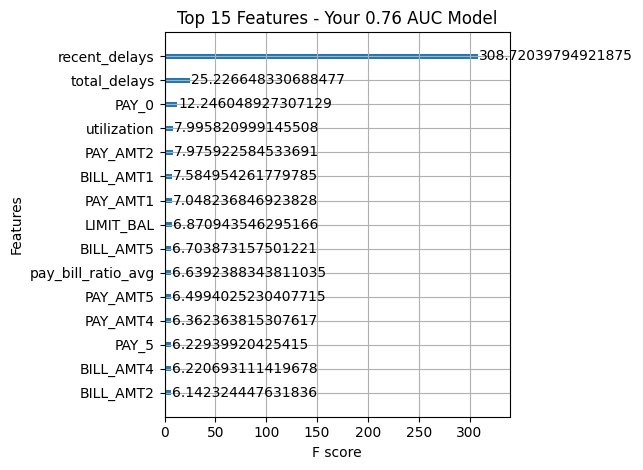

In [102]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Your trained model (the 0.76 one)
plot_importance(final_model, max_num_features=15, importance_type='gain')
plt.title('Top 15 Features - Your 0.76 AUC Model')
plt.tight_layout()
plt.show()

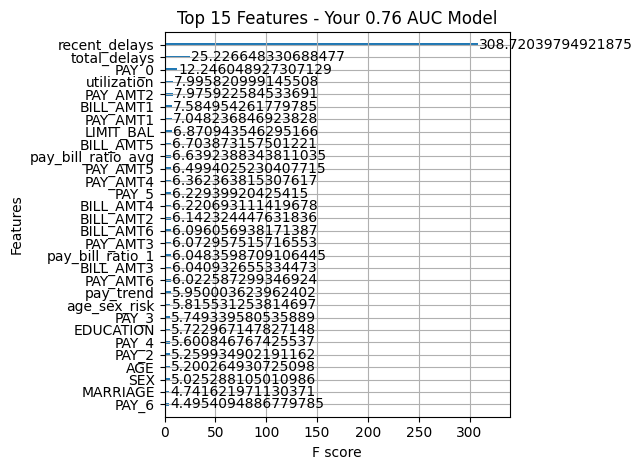

In [103]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Your trained model (the 0.76 one)
plot_importance(final_model, importance_type='gain')
plt.title('Top 15 Features - Your 0.76 AUC Model')
plt.tight_layout()
plt.show()

/Users/nicholus/Documents/GitHub/credit-card-default/card_default/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


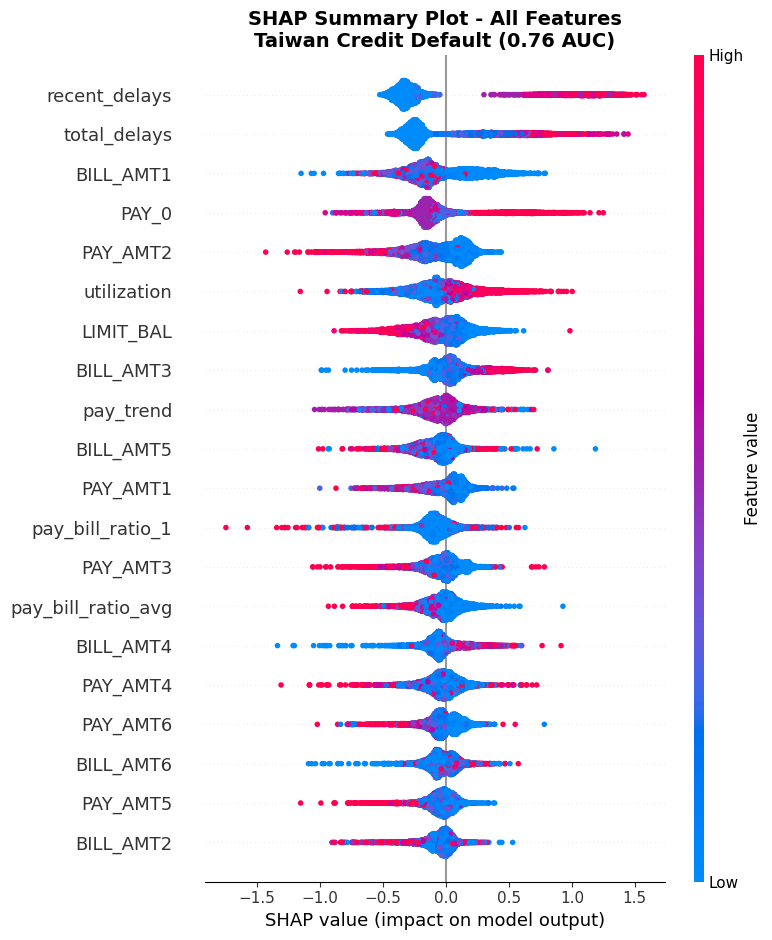

In [104]:
# SHAP
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Your trained model (0.76 AUC one)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)  # Positive class only for binary

# 1. SUMMARY PLOT - ALL FEATURES (beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, show=False, max_display=20)
plt.title('SHAP Summary Plot - All Features\nTaiwan Credit Default (0.76 AUC)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

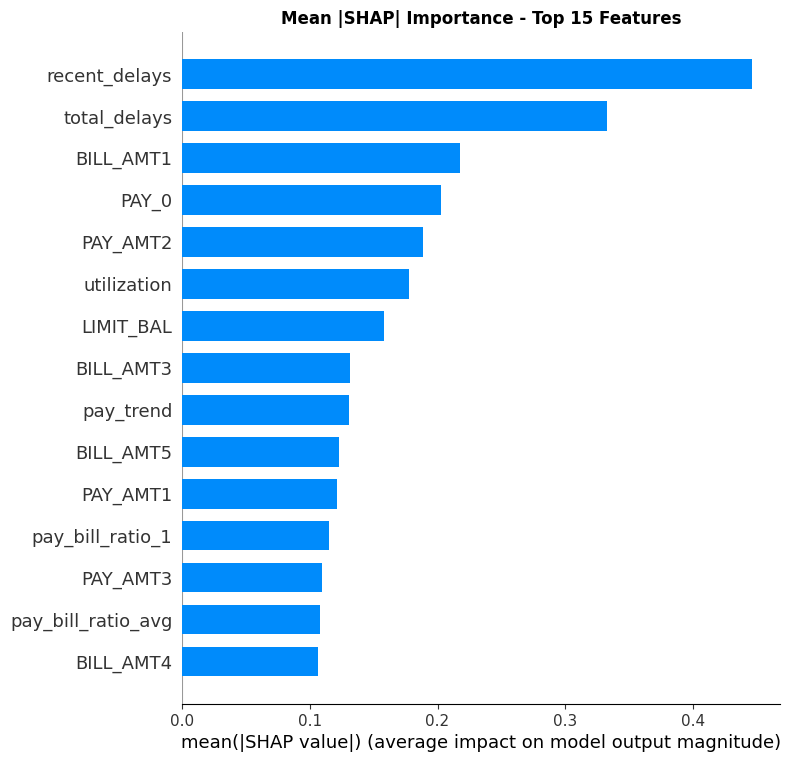

In [105]:
# bar plot

# Mean absolute SHAP values = true feature importance
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, 
                  plot_type="bar", max_display=15, show=False)
plt.title('Mean |SHAP| Importance - Top 15 Features', fontweight='bold')
plt.show()

In [106]:
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, show=False)
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.close()

shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, plot_type="bar", show=False)
plt.savefig('shap_importance.png', dpi=300, bbox_inches='tight')
plt.close()